![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [4]:
import matplotlib.pyplot as plt 
import pandas as pd

In [39]:
!pip install seaborn --upgrade

,Requirement already satisfied: numpy!=1.24.0,>=1.20 in /opt/anaconda3/lib/python3.13/site-packages (from seaborn) (2.3.5)
,Requirement already satisfied: pandas>=1.2 in /opt/anaconda3/lib/python3.13/site-packages (from seaborn) (2.3.3)
,Requirement already satisfied: matplotlib!=3.6.1,>=3.4 in /opt/anaconda3/lib/python3.13/site-packages (from seaborn) (3.10.6)
,Requirement already satisfied: contourpy>=1.0.1 in /opt/anaconda3/lib/python3.13/site-packages (from matplotlib!=3.6.1,>=3.4->seaborn) (1.3.3)
,Requirement already satisfied: cycler>=0.10 in /opt/anaconda3/lib/python3.13/site-packages (from matplotlib!=3.6.1,>=3.4->seaborn) (0.11.0)
,Requirement already satisfied: fonttools>=4.22.0 in /opt/anaconda3/lib/python3.13/site-packages (from matplotlib!=3.6.1,>=3.4->seaborn) (4.60.1)
,Requirement already satisfied: kiwisolver>=1.3.1 in /opt/anaconda3/lib/python3.13/site-packages (from matplotlib!=3.6.1,>=3.4->seaborn) (1.4.9)
,Requirement already satisfied: packaging>=20.0 in /opt/anac

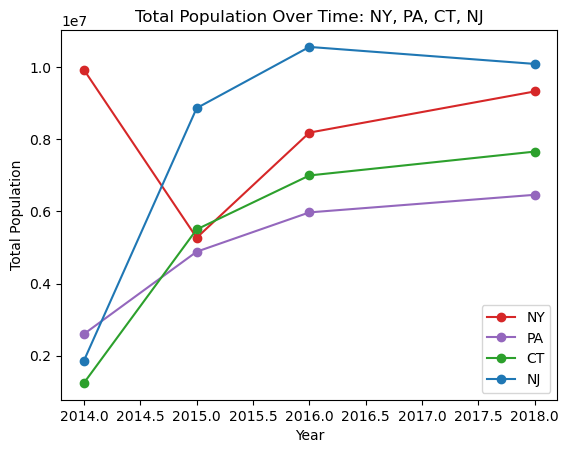

In [33]:
#Question 1
cities = pd.read_csv('us-cities-top-1k-multi-year.csv') #File
state = cities[cities["State"].isin(["New York", "Pennsylvania", "Connecticut", "New Jersey"])] #delete any other state
state_time = state.groupby(["year", "State"])["Population"].sum().reset_index() #takes the population of a given state and assigns both to another list, ignoring the other categories, compiles to one big list

#splits up the big state_time list to many small lists per state
ny = state_time[state_time["State"] == "New York"]
pa = state_time[state_time["State"] == "Pennsylvania"]
ct = state_time[state_time["State"] == "Connecticut"]
nj = state_time[state_time["State"] == "New Jersey"]

#Plots the lines, and then labels the axis, and then shows the graph
plt.plot(ny["year"], ny["Population"], color="tab:red", label="NY", marker='o')
plt.plot(pa["year"], pa["Population"], color="tab:purple", label="PA", marker='o')
plt.plot(ct["year"], ct["Population"], color="tab:green", label="CT", marker='o')
plt.plot(nj["year"], nj["Population"], color="tab:blue", label="NJ", marker='o')
plt.xlabel("Year")
plt.ylabel("Total Population of States")
plt.title("Total Population Over Time: NY, PA, CT, NJ")

plt.legend()
plt.show()

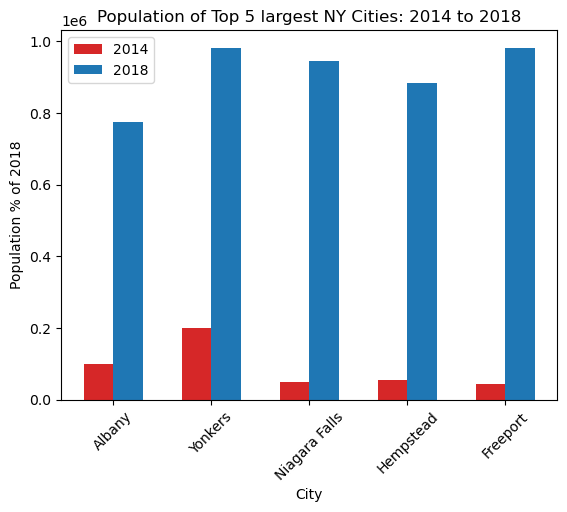

In [47]:
#Question 2 
NYcities = cities[cities["State"] == "New York"] #seperates cities from new york, seperates them to one list

top5cities = (NYcities[NYcities["year"] == 2018].sort_values("Population", ascending=False).head(5)["City"]) #creates a list of the top 5 cities
NYcompare = NYcities[(NYcities["City"].isin(top5cities)) & (NYcities["year"].isin([2014, 2018]))] #assigns each city to its 2014 and 2018 population values in one giant dictionary
NYpop2014 = NYcompare[NYcompare["year"] == 2014].set_index("City")["Population"] # assigns 2014 values to a new dictionary
NYpop2018 = NYcompare[NYcompare["year"] == 2018].set_index("City")["Population"] #assigns 2018 values to a new dictinonary

#arranges the graph to show all the bars, making sure they dont overlap, then labels the graph and arranges it to the largest cities
r1 = np.arange(len(NYpop2014))
r2 = [x + barWidth for x in r1]
plt.bar(r1, NYpop2014, color="tab:red", width=barWidth, label="2014")
plt.bar(r2, NYpop2018, color="tab:blue", width=barWidth, label="2018")
plt.xlabel("City")
plt.xticks([r + barWidth/2 for r in range(len(NYpop2014))], NYpop2014.index, rotation=45)
plt.ylabel("Population % of 2018")
plt.title("Population of Top 5 largest NY Cities: 2014 to 2018")
plt.legend()
plt.show()

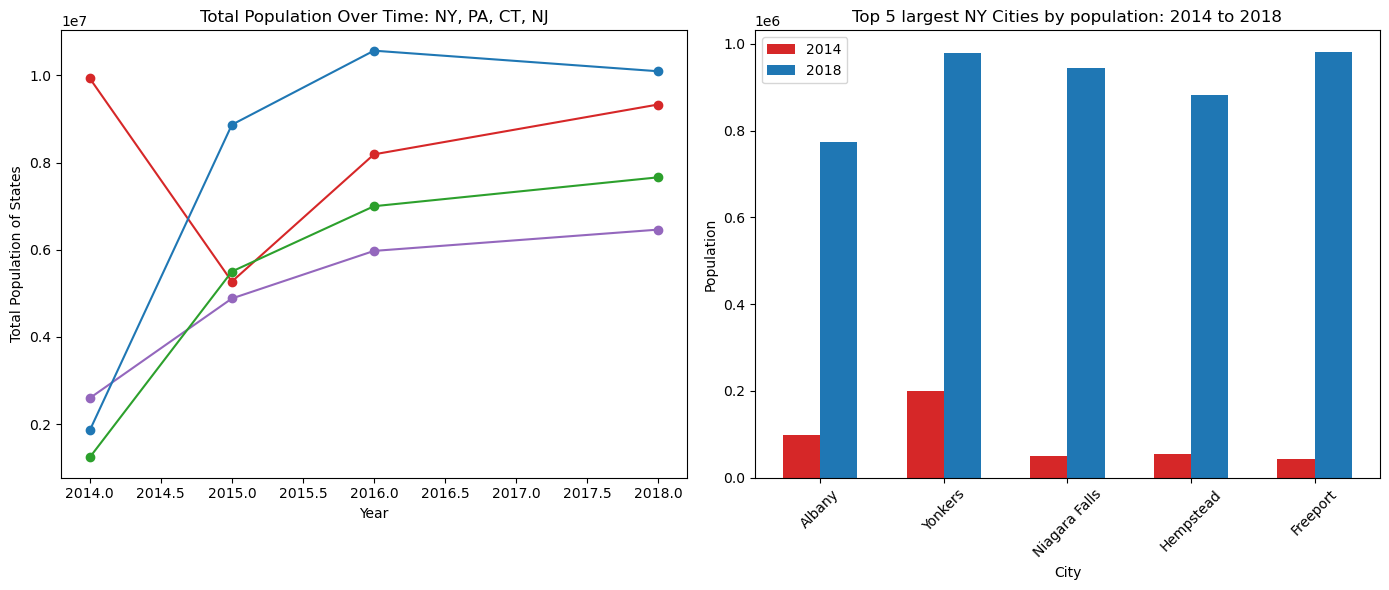

In [55]:
plt.figure(figsize=(14,6))

# Graph 1 
plt.subplot(1, 2, 1)
plt.plot(ny["year"], ny["Population"], color="tab:red", label="NY", marker='o')
plt.plot(pa["year"], pa["Population"], color="tab:purple", label="PA", marker='o')
plt.plot(ct["year"], ct["Population"], color="tab:green", label="CT", marker='o')
plt.plot(nj["year"], nj["Population"], color="tab:blue", label="NJ", marker='o')
plt.xlabel("Year")
plt.ylabel("Total Population of States")
plt.title("Total Population Over Time: NY, PA, CT, NJ")


plt.subplot(1, 2, 2)
r1 = np.arange(len(NYpop2014))
r2 = [x + barWidth for x in r1]
plt.bar(r1, NYpop2014, color="tab:red", width=barWidth, label="2014")
plt.bar(r2, NYpop2018, color="tab:blue", width=barWidth, label="2018")
plt.xlabel("City")
plt.xticks([r + barWidth/2 for r in range(len(NYpop2014))], NYpop2014.index, rotation=45)
plt.ylabel("Population")
plt.title("Top 5 largest NY Cities by population: 2014 to 2018")

plt.legend()
plt.tight_layout()
plt.show()

In [16]:
#Question 2
job = pd.read_csv("job-automation-probability.csv")
job

,_ - rank,_ - code,prob,Average annual wage,education,occupation,short occupation,len,probability,numbEmployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.9500,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,0.9500,74600,32890.0,74600,34920.0
1,517,51-9012,0.8800,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,0.8800,47160,38360.0,47160,41450.0
2,484,41-4012,0.8500,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,0.8500,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.0290,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,0.0290,202760,57270.0,202760,59800.0
4,620,51-4072,0.9500,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,0.9500,145560,30480.0,145560,32660.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,259,27-2011,0.3700,71313.6,"Some college, no degree",Actors,Actors,6,0.3700,48620,33473.0,48620,71313.6
698,522,51-3011,0.8900,27110.0,No formal educational credential,Bakers,Bakers,6,0.8900,180450,25090.0,180450,27110.0
699,42,21-2011,0.0081,49450.0,Bachelor's degree,Clergy,Clergy,6,0.0081,49320,45740.0,49320,49450.0
700,669,41-9012,0.9800,36560.0,No formal educational credential,Models,Models,6,0.9800,4390,21870.0,4390,36560.0


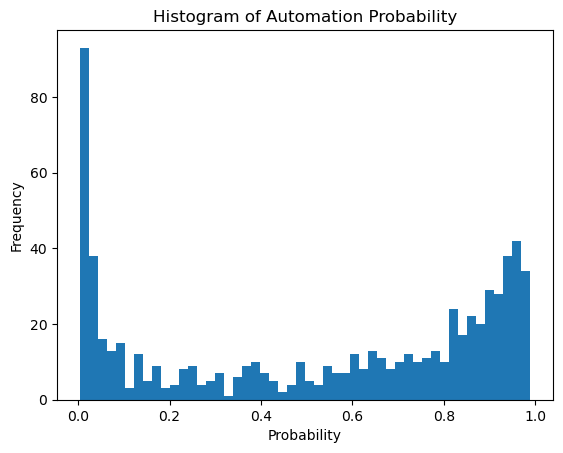

In [17]:
#Histogram
plt.hist(job["probability"], bins=50,)
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Automation Probability")
plt.show()

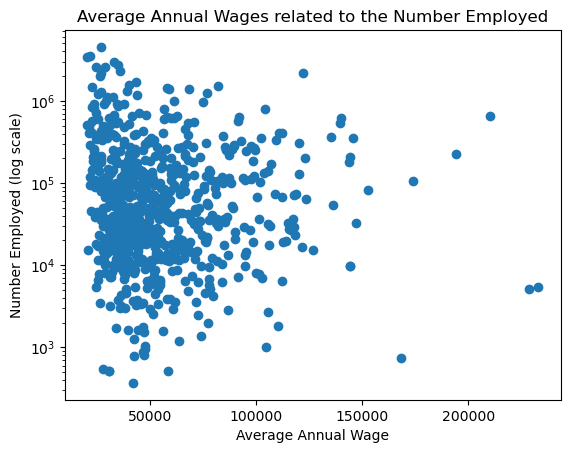

In [57]:
#Scatterplot
plt.scatter(job ["Average annual wage"], job["numbEmployed"])
plt.yscale("log")
plt.xlabel("Average Annual Wage")
plt.ylabel("Number Employed (log scale)")
plt.title("Average Annual Wages related to the Number Employed")
plt.show()

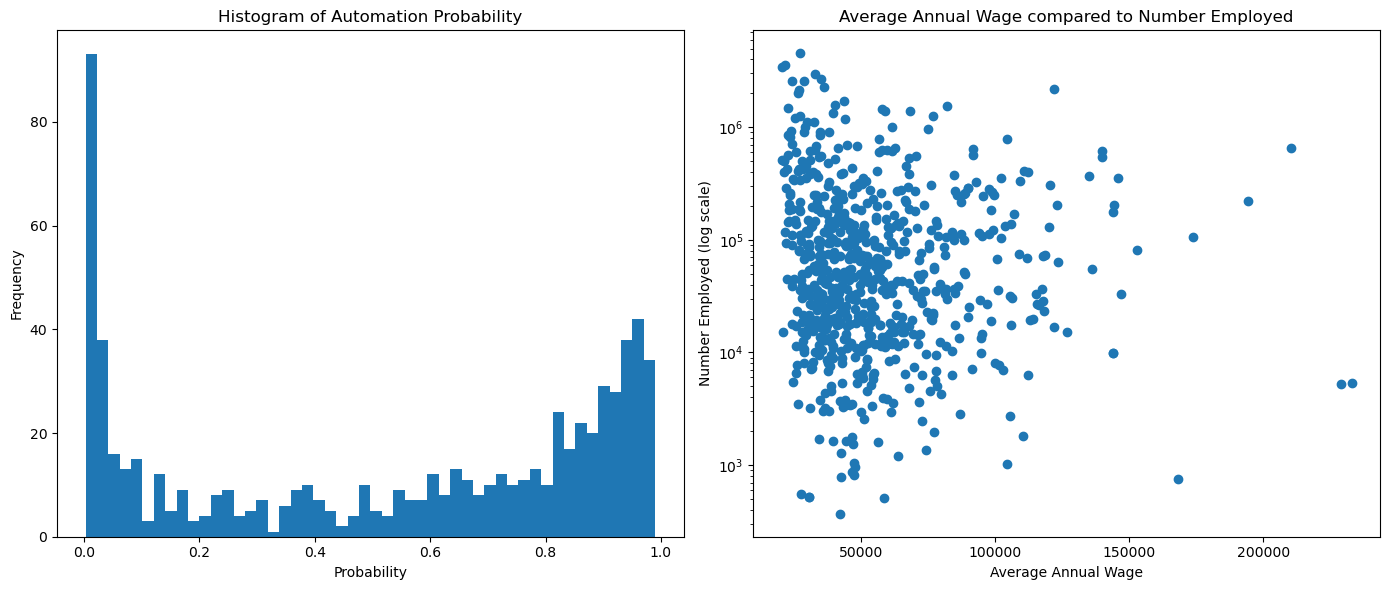

In [59]:
plt.figure(figsize=(14,6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(job["probability"], bins=50)
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Automation Probability")

# Scatter plot 
plt.subplot(1, 2, 2)
plt.scatter(job["Average annual wage"], job["numbEmployed"])
plt.yscale("log")  
plt.xlabel("Average Annual Wage")
plt.ylabel("Number Employed (log scale)")
plt.title("Average Annual Wage compared to Number Employed")
plt.tight_layout()
plt.savefig("scatterplot3.png")
plt.show()